In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df = pd.read_csv("Mall_Customers.csv")

df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [2]:
df.shape

(200, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

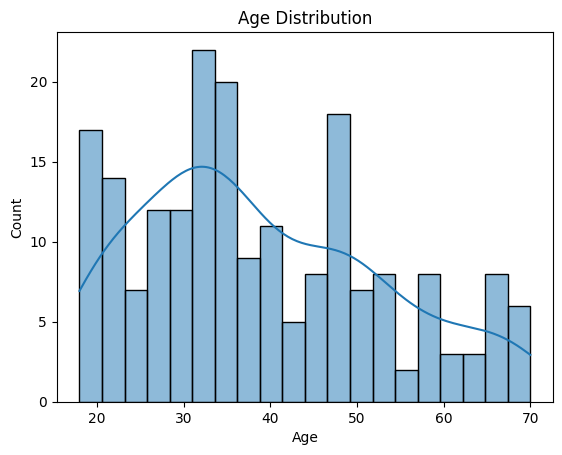

In [6]:
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

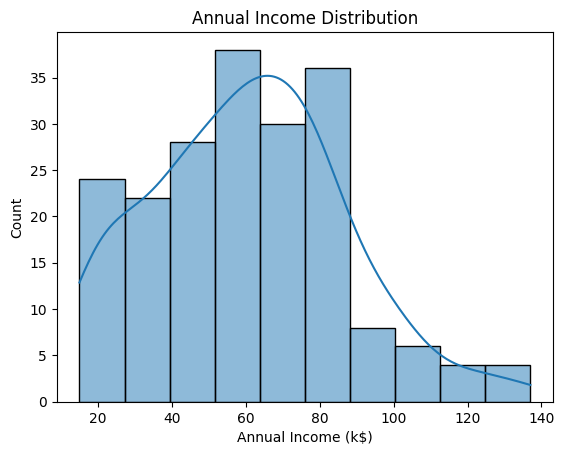

In [7]:
sns.histplot(df["Annual Income (k$)"],kde=True)
plt.title("Annual Income Distribution")
plt.show()

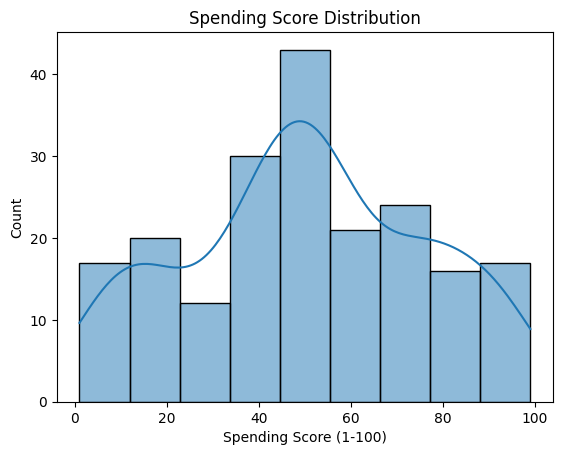

In [8]:
sns.histplot(df["Spending Score (1-100)"],kde=True)
plt.title("Spending Score Distribution")
plt.show()

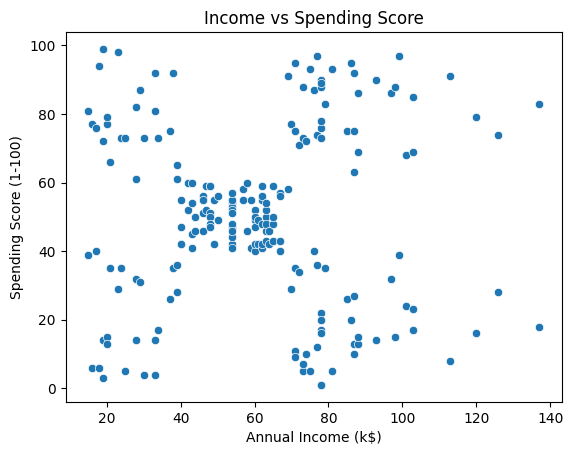

In [9]:
sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"]
)

plt.title("Income vs Spending Score")
plt.show()

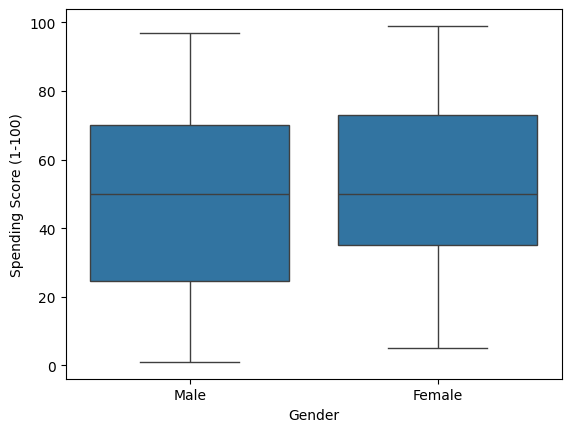

In [10]:
sns.boxplot(
    x="Gender",
    y="Spending Score (1-100)",
    data=df
)

plt.show()

In [11]:
df = df.drop("CustomerID", axis=1)

In [12]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [13]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

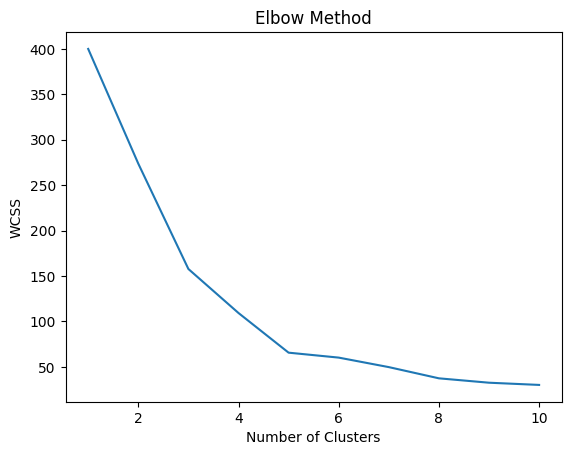

In [15]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

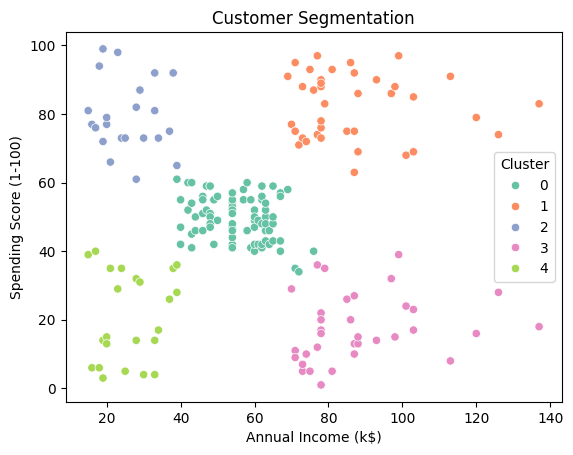

In [17]:
sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="Set2"
)
plt.title("Customer Segmentation")
plt.show()

In [18]:
df.groupby("Cluster").mean()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.407407,42.716049,55.296296,49.518519
1,0.461538,32.692308,86.538462,82.128205
2,0.409091,25.272727,25.727273,79.363636
3,0.542857,41.114286,88.200000,17.114286
4,0.391304,45.217391,26.304348,20.913043


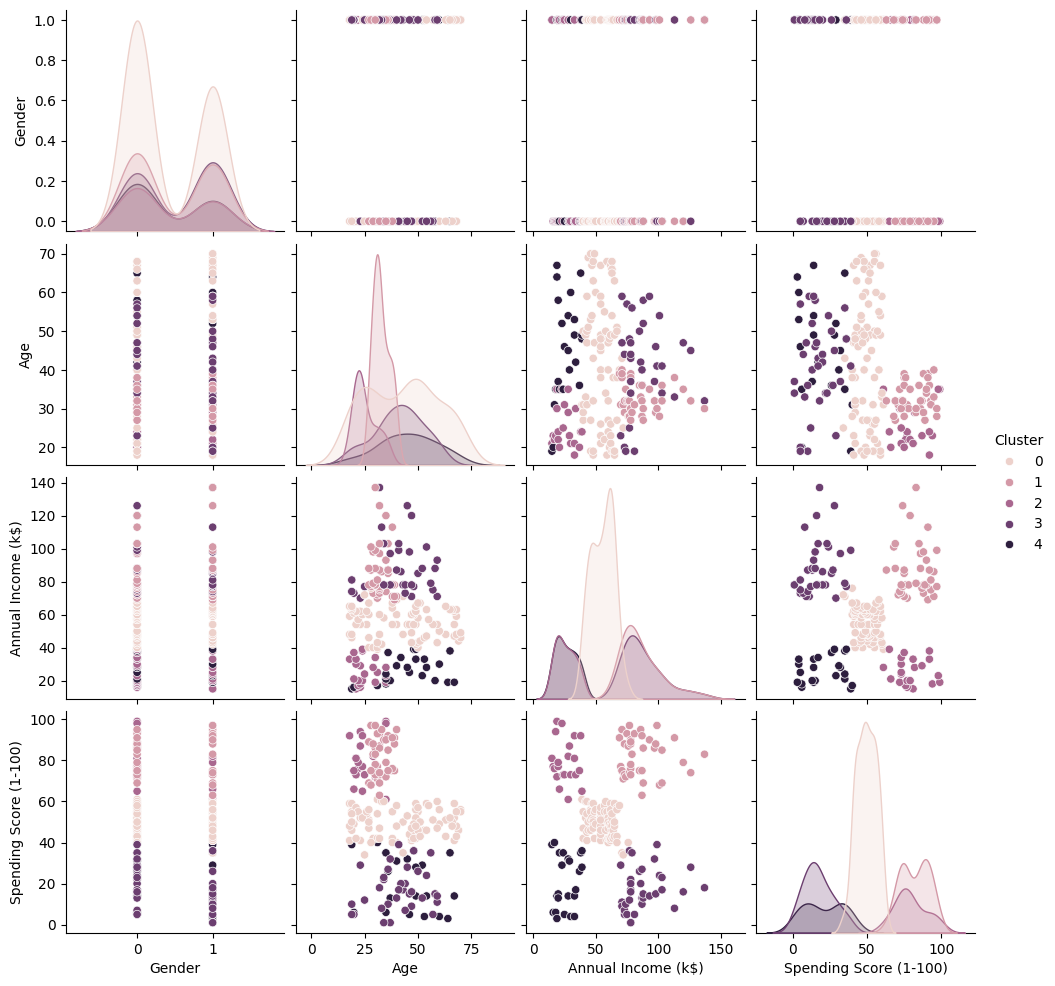

In [19]:
sns.pairplot(df, hue="Cluster")

<Axes: >

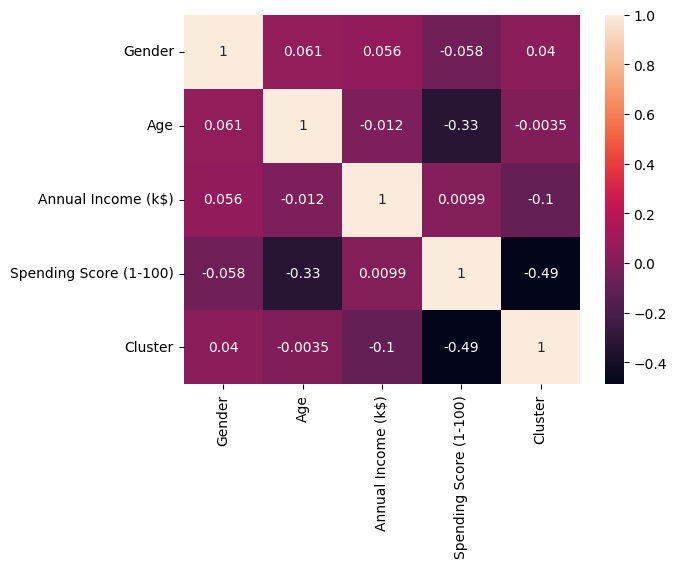

In [20]:
sns.heatmap(df.corr(), annot=True)

In [21]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, clusters)
print("Score :",score)

Score : 0.5546571631111091


In [22]:
df.groupby("Cluster").mean()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.407407,42.716049,55.296296,49.518519
1,0.461538,32.692308,86.538462,82.128205
2,0.409091,25.272727,25.727273,79.363636
3,0.542857,41.114286,88.200000,17.114286
4,0.391304,45.217391,26.304348,20.913043
